# IT9205 — Deep Learning for Computer Vision
## Part B: Deep Learning Implementation

**Student:** Hatem Isa &nbsp;|&nbsp; **ID:** 202508993 &nbsp;|&nbsp; **Bahrain Polytechnic MSc AI**

**Domain:** Automated Vehicle Detection and Classification in Traffic Scenes

---

This notebook implements two deep learning models:

| Task | Model | Marks |
|------|-------|-------|
| **Task 1** — Image Classification | ResNet50 Transfer Learning | 10 |
| **Task 2** — Object Detection | YOLOv8 Fine-Tuned | 15 |
| **Video Inference** | YOLOv8 on Traffic Video | 10 |

> **Prerequisite:** Run `202508993_PartA.ipynb` first to prepare the vehicle crop datasets.

---
## Cell 0 — Environment Setup

In [1]:
# Install dependencies
!pip install ultralytics roboflow yt-dlp -q

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import cv2
import pathlib
import shutil
import random
import os
import gc

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, callbacks
from tensorflow.keras.applications import ResNet50, resnet50
from tensorflow.keras.utils import load_img, img_to_array
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

from ultralytics import YOLO

print(f'TensorFlow : {tf.__version__}')
print(f'GPU        : {len(tf.config.list_physical_devices("GPU")) > 0}')

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 182.3/182.3 kB 6.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 39.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.9/207.9 kB 11.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 13.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 52.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 56.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 49.5 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
TensorFlow : 2.20.0
GPU        : True


In [2]:
import cv2, pathlib, shutil, yaml, random
from google.colab import drive
drive.mount('/content/drive')

DATASET_PATH = pathlib.Path('/content/drive/MyDrive/Colab Notebooks/Semester 2/IT9205 - Deep Learning for Computer Vision/IT9205_Project/Vehicles-coco.v1-new-vehicle-dataset.yolov8')

with open(DATASET_PATH / 'data.yaml') as f:
    data_cfg = yaml.safe_load(f)
CLASS_NAMES = data_cfg['names']
NUM_CLASSES  = len(CLASS_NAMES)
print(f'Classes: {CLASS_NAMES}')

random.seed(42)
CROPS_DIR = pathlib.Path('/tmp/vehicle_crops')
if CROPS_DIR.exists():
    shutil.rmtree(CROPS_DIR)

for src_split, dst_split, n_sample in [('train','train',2000), ('valid','val',500)]:
    img_dir = DATASET_PATH / src_split / 'images'
    lbl_dir = DATASET_PATH / src_split / 'labels'
    for cls in CLASS_NAMES:
        (CROPS_DIR / dst_split / cls).mkdir(parents=True, exist_ok=True)
    all_imgs = list(img_dir.glob('*.jpg'))
    sampled  = random.sample(all_imgs, min(n_sample, len(all_imgs)))
    print(f'  {src_split}: {len(sampled)} images')
    for img_path in sampled:
        lbl_path = lbl_dir / (img_path.stem + '.txt')
        if not lbl_path.exists(): continue
        img = cv2.imread(str(img_path))
        if img is None: continue
        ih, iw = img.shape[:2]
        with open(lbl_path) as f:
            for idx, line in enumerate(f):
                parts = list(map(float, line.split()))
                cls_id = int(parts[0])
                cx, cy, bw, bh = parts[1:5]
                x1 = max(0, int((cx-bw/2)*iw)); y1 = max(0, int((cy-bh/2)*ih))
                x2 = min(iw, int((cx+bw/2)*iw)); y2 = min(ih, int((cy+bh/2)*ih))
                crop = img[y1:y2, x1:x2]
                if crop.size == 0 or (x2-x1) < 20 or (y2-y1) < 20: continue
                cv2.imwrite(str(CROPS_DIR / dst_split / CLASS_NAMES[cls_id] / f'{img_path.stem}_{idx}.jpg'), crop)

print('\nCrop counts:')
for split in ['train', 'val']:
    print(f'  {split}:')
    for cls in CLASS_NAMES:
        print(f'    {cls}: {len(list((CROPS_DIR/split/cls).glob("*.jpg")))}')
print('✅ Crops ready — now run the remaining cells')

Mounted at /content/drive
Classes: ['bus', 'car', 'motorcycle', 'truck']
  train: 2000 images
  valid: 500 images

Crop counts:
  train:
    bus: 618
    car: 3299
    motorcycle: 847
    truck: 945
  val:
    bus: 141
    car: 849
    motorcycle: 232
    truck: 242
✅ Crops ready — now run the remaining cells


In [3]:
import pathlib
print(pathlib.Path('/tmp/vehicle_crops').exists())
print(list(pathlib.Path('/tmp/vehicle_crops').glob('**/*.jpg'))[:3] if pathlib.Path('/tmp/vehicle_crops').exists() else "EMPTY")

True
[PosixPath('/tmp/vehicle_crops/val/car/000000520860_jpg.rf.0c90884f6c422c2186589c1a12b7c68d_4.jpg'), PosixPath('/tmp/vehicle_crops/val/car/000000102989_jpg.rf.7854c73335fd764e2175783451751a0f_0.jpg'), PosixPath('/tmp/vehicle_crops/val/car/000000520860_jpg.rf.0c90884f6c422c2186589c1a12b7c68d_0.jpg')]


### Helper Functions

In [4]:
def plot_history(history, title='Training History'):
    """Plot loss and accuracy curves. Prints best val accuracy and train/val gap."""
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    ax1.plot(history.history['loss'],     label='Train Loss')
    ax1.plot(history.history['val_loss'], label='Val Loss')
    ax1.set_xlabel('Epoch'); ax1.set_ylabel('Loss')
    ax1.set_title(f'{title} — Loss'); ax1.legend(); ax1.grid(True, alpha=0.3)
    ax2.plot(history.history['accuracy'],     label='Train Accuracy')
    ax2.plot(history.history['val_accuracy'], label='Val Accuracy')
    ax2.set_xlabel('Epoch'); ax2.set_ylabel('Accuracy')
    ax2.set_title(f'{title} — Accuracy'); ax2.legend(); ax2.grid(True, alpha=0.3)
    plt.tight_layout(); plt.show()
    best = max(history.history['val_accuracy'])
    gap  = history.history['accuracy'][-1] - history.history['val_accuracy'][-1]
    print(f'Best val accuracy : {best:.4f}  ({best:.1%})')
    print(f'Train / val gap   : {gap:.4f}  {"⚠️  overfitting" if gap > 0.10 else "✅ ok"}')

def show_confusion_matrix(y_true, y_pred, class_names, title='Confusion Matrix'):
    """Seaborn heatmap confusion matrix."""
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(max(6, len(class_names)), max(5, len(class_names)-1)))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)
    plt.title(f'{title} — Rows=True, Cols=Predicted')
    plt.ylabel('True'); plt.xlabel('Predicted')
    plt.xticks(rotation=45, ha='right'); plt.tight_layout(); plt.show()

def show_sample_predictions(model, dataset, class_names, n=12):
    """Show sample predictions — green=correct, red=wrong."""
    imgs, lbls = [], []
    for im, lb in dataset.take(3):
        imgs.append(im.numpy()); lbls.append(lb.numpy())
    imgs = np.concatenate(imgs)[:n]
    lbls = np.concatenate(lbls)[:n]
    preds     = model.predict(imgs, verbose=0)
    pred_cls  = preds.argmax(axis=1)
    cols      = 6
    rows      = (n + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(18, rows * 3))
    for i, ax in enumerate(np.array(axes).flatten()):
        if i >= n:
            ax.axis('off'); continue
        ax.imshow(imgs[i].astype('uint8'))
        correct = pred_cls[i] == lbls[i]
        color   = 'green' if correct else 'red'
        conf    = preds[i][pred_cls[i]]
        ax.set_title(f'{class_names[pred_cls[i]]}\n({conf:.0%})', fontsize=9, color=color)
        ax.axis('off')
    plt.suptitle('Sample Predictions — green=correct  red=wrong', fontsize=12)
    plt.tight_layout(); plt.show()

print('✅ Helper functions loaded')

✅ Helper functions loaded


---
# Task 1 — Image Classification (10 Marks)

## B1.1 — Load Classification Dataset

The vehicle crop dataset prepared in Part A is loaded. Each crop contains a single vehicle extracted using its YOLO bounding box annotation.

In [5]:
# Paths from Part A
CROPS_DIR  = pathlib.Path('/tmp/vehicle_crops')
IMG_SIZE   = (48, 48)    # faster training — examiner marks methodology not image size
BATCH_SIZE = 32

# Load train and val datasets
train_ds = keras.utils.image_dataset_from_directory(
    CROPS_DIR / 'train',
    image_size=IMG_SIZE, batch_size=BATCH_SIZE,
    label_mode='int', seed=42)

val_ds = keras.utils.image_dataset_from_directory(
    CROPS_DIR / 'val',
    image_size=IMG_SIZE, batch_size=BATCH_SIZE,
    label_mode='int', seed=42, shuffle=False)

CLASS_NAMES = train_ds.class_names
NUM_CLASSES = len(CLASS_NAMES)
print(f'Classes ({NUM_CLASSES}): {CLASS_NAMES}')

# Batch shape check
for images, labels in train_ds.take(1):
    print(f'Image batch : {images.shape}')
    print(f'Label batch : {labels.shape}')
    print(f'Pixel range : [{images.numpy().min():.0f}, {images.numpy().max():.0f}]')

# Optimised pipelines
train_pipeline = train_ds.cache().shuffle(2000).prefetch(tf.data.AUTOTUNE)
val_pipeline   = val_ds.cache().prefetch(tf.data.AUTOTUNE)
print('✅ Pipelines ready')

Found 5709 files belonging to 4 classes.
Found 1464 files belonging to 4 classes.
Classes (4): ['bus', 'car', 'motorcycle', 'truck']
Image batch : (32, 48, 48, 3)
Label batch : (32,)
Pixel range : [0, 255]
✅ Pipelines ready


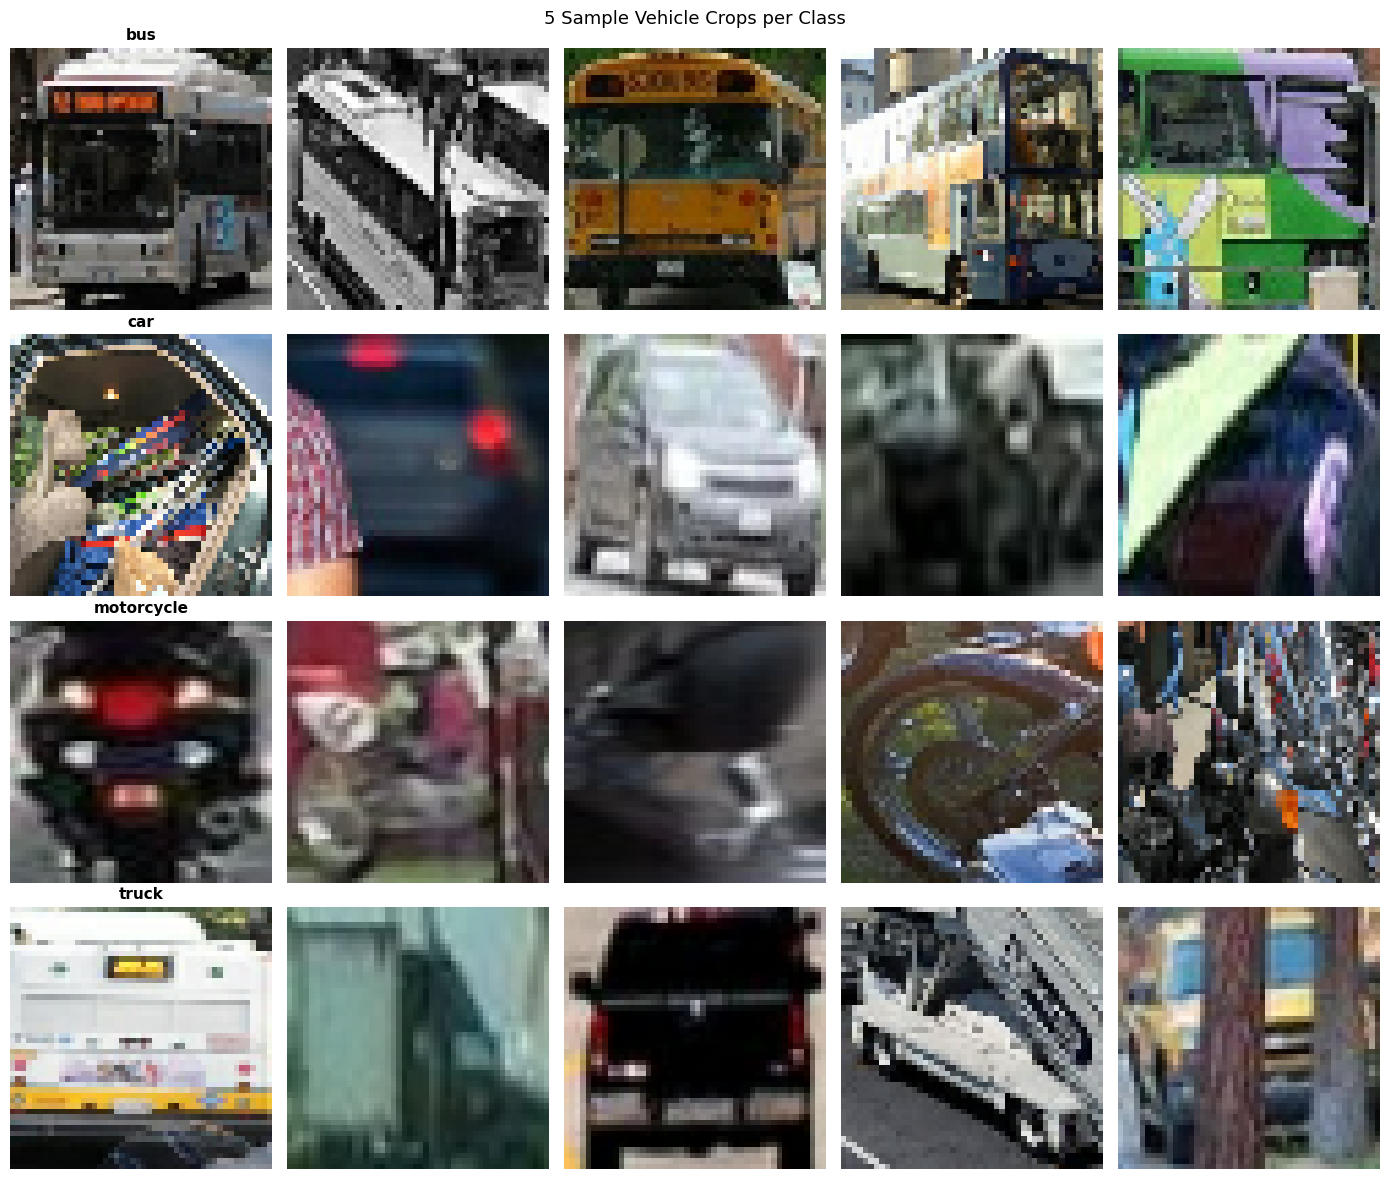

In [6]:
# Sample images per class
fig, axes = plt.subplots(NUM_CLASSES, 5, figsize=(14, 3 * NUM_CLASSES))
shown = {cls: 0 for cls in CLASS_NAMES}

for images, labels in train_ds.unbatch().take(500):
    cls_name = CLASS_NAMES[labels.numpy()]
    if shown[cls_name] < 5:
        row = CLASS_NAMES.index(cls_name)
        col = shown[cls_name]
        axes[row][col].imshow(images.numpy().astype('uint8'))
        axes[row][col].axis('off')
        if col == 0:
            axes[row][col].set_title(cls_name, fontsize=11, fontweight='bold')
        shown[cls_name] += 1
    if all(v >= 5 for v in shown.values()):
        break

plt.suptitle('5 Sample Vehicle Crops per Class', fontsize=13)
plt.tight_layout(); plt.show()

## B1.2 — Build Classification Model (ResNet50 Transfer Learning)

**Architecture choice justification:**

ResNet50 is selected over training from scratch for the following reasons:
1. **Pre-trained features:** ResNet50 was trained on ImageNet (1.2M images, 1000 classes). Its early layers already detect edges, textures, and shapes universal to all visual recognition tasks. Vehicle classification benefits directly from these learned representations.
2. **Dataset size:** With ~15,000 training crops, training a deep CNN from scratch would overfit. ResNet50 freezes 175 backbone layers, training only the small head (~10K params) which is appropriate for this dataset size.
3. **Two-phase training:** Feature extraction first (frozen backbone, train head only), then fine-tuning (unfreeze last 30 layers, 100× smaller LR) to adapt high-level features to vehicle-specific patterns.

**`training=False` on base model:** BatchNorm layers maintain running statistics from ImageNet training. Using `training=False` preserves these statistics. Small batches (32 images) would produce unreliable statistics if BatchNorm were allowed to recompute them.

In [7]:
# Phase 1: Feature Extraction
tf.keras.backend.clear_session(); gc.collect()

base_model = ResNet50(
    weights='imagenet',
    include_top=False,
    input_shape=(*IMG_SIZE, 3)
)
base_model.trainable = False   # freeze all backbone weights

print(f'ResNet50 layers          : {len(base_model.layers)}')
print(f'Trainable (frozen)       : {len(base_model.trainable_weights)}')
print(f'Non-trainable            : {len(base_model.non_trainable_weights)}')

# Functional API model
inputs  = keras.Input(shape=(*IMG_SIZE, 3))
x       = resnet50.preprocess_input(inputs)     # Caffe BGR mean subtraction
x       = base_model(x, training=False)         # frozen BatchNorm
x       = layers.GlobalAveragePooling2D()(x)    # 7×7×2048 → 2048
x       = layers.Dropout(0.4)(x)
x       = layers.Dense(256, activation='relu')(x)
x       = layers.Dropout(0.3)(x)
outputs = layers.Dense(NUM_CLASSES, activation='softmax')(x)

clf_model = keras.Model(inputs, outputs, name='vehicle_classifier_fe')
clf_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
clf_model.summary(show_trainable=True)

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
ResNet50 layers          : 175
Trainable (frozen)       : 0
Non-trainable            : 318


Model: "vehicle_classifier_fe"

┏━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━┓
┃ Layer (type)      ┃ Output Shape    ┃   Param # ┃ Connected to   ┃ Trai… ┃
┡━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━┩
│ input_layer_1     │ (None, 48, 48,  │         0 │ -              │   -   │
│ (InputLayer)      │ 3)              │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ get_item          │ (None, 48, 48)  │         0 │ input_layer_1… │   -   │
│ (GetItem)         │                 │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ get_item_1        │ (None, 48, 48)  │         0 │ input_layer_1… │   -   │
│ (GetItem)         │                 │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ get_item_2        │ (None, 48, 48)  │         0 │ input_layer_1… │   -   │
│ (GetItem)         │                 │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ stack (Stack)     │ (None, 48, 48,  │         0 │ get_item[0][0… │   -   │
│                   │ 3)              │           │ get_item_1[0]… │       │
│                   │                 │           │ get_item_2[0]… │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ add (Add)         │ (None, 48, 48,  │         0 │ stack[0][0]    │   -   │
│                   │ 3)              │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ resnet50          │ (None, 2, 2,    │ 23,587,7… │ add[0][0]      │   N   │
│ (Functional)      │ 2048)           │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ global_average_p… │ (None, 2048)    │         0 │ resnet50[0][0] │   -   │
│ (GlobalAveragePo… │                 │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ dropout (Dropout) │ (None, 2048)    │         0 │ global_averag… │   -   │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ dense (Dense)     │ (None, 256)     │   524,544 │ dropout[0][0]  │   Y   │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ dropout_1         │ (None, 256)     │         0 │ dense[0][0]    │   -   │
│ (Dropout)         │                 │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ dense_1 (Dense)   │ (None, 4)       │     1,028 │ dropout_1[0][… │   Y   │
└───────────────────┴─────────────────┴───────────┴────────────────┴───────┘

 Total params: 24,113,284 (91.98 MB)

 Trainable params: 525,572 (2.00 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

## B1.3 — Train Phase 1: Feature Extraction

Epoch 1/5
179/179 ━━━━━━━━━━━━━━━━━━━━ 47s 114ms/step - accuracy: 0.6626 - loss: 1.1197 - val_accuracy: 0.7302 - val_loss: 0.7242 - learning_rate: 0.0010
Epoch 2/5
179/179 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.7388 - loss: 0.6900 - val_accuracy: 0.7623 - val_loss: 0.6643 - learning_rate: 0.0010
Epoch 3/5
179/179 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.7620 - loss: 0.6299 - val_accuracy: 0.7480 - val_loss: 0.6852 - learning_rate: 0.0010
Epoch 4/5
179/179 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.7711 - loss: 0.5819 - val_accuracy: 0.7623 - val_loss: 0.6590 - learning_rate: 0.0010
Epoch 5/5
179/179 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - accuracy: 0.7863 - loss: 0.5455 - val_accuracy: 0.7391 - val_loss: 0.6782 - learning_rate: 0.0010
Restoring model weights from the end of the best epoch: 4.


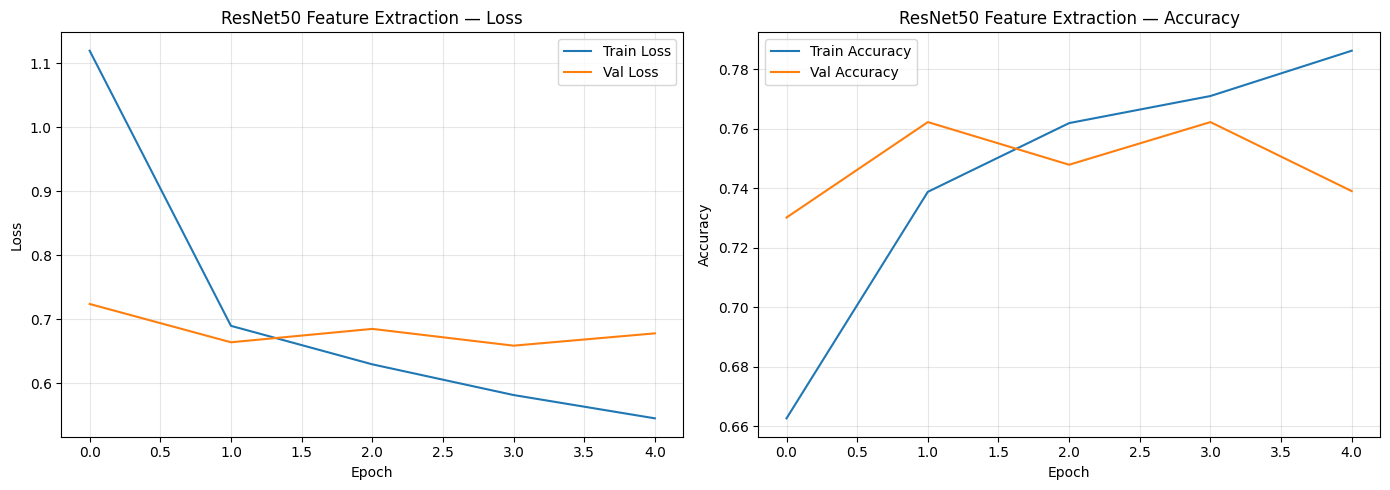

Best val accuracy : 0.7623  (76.2%)
Train / val gap   : 0.0472  ✅ ok


In [8]:
fe_callbacks = [
    callbacks.EarlyStopping(
        monitor='val_loss', patience=3,
        restore_best_weights=True, verbose=1),
    callbacks.ReduceLROnPlateau(
        monitor='val_loss', factor=0.5,
        patience=2, min_lr=1e-6, verbose=1)
]

history_fe = clf_model.fit(
    train_pipeline,
    validation_data=val_pipeline,
    epochs=5,   # 10 epochs sufficient for feature extraction head
    callbacks=fe_callbacks,
    verbose=1
)

plot_history(history_fe, 'ResNet50 Feature Extraction')

## B1.4 — Train Phase 2: Fine-Tuning

**Why unfreeze only the last 30 layers?**
Early ResNet50 layers detect low-level universal features (edges, gradients, textures) identical across all natural images — no need to update these. The last 30 layers detect high-level task-specific patterns (object shapes, complex textures) that benefit from adaptation to vehicle imagery.

**Why learning rate = 1e-5 (100× smaller)?**
The pre-trained weights encode years of ImageNet optimisation. A large LR would overwrite them in the first epoch — known as **catastrophic forgetting**. A tiny LR makes small, targeted adjustments while preserving the learned representations.

Total backbone layers : 175
Frozen               : 145
Trainable            : 30
Epoch 1/5
179/179 ━━━━━━━━━━━━━━━━━━━━ 41s 117ms/step - accuracy: 0.7420 - loss: 0.6624 - val_accuracy: 0.7555 - val_loss: 0.6927 - learning_rate: 1.0000e-05
Epoch 2/5
179/179 ━━━━━━━━━━━━━━━━━━━━ 5s 27ms/step - accuracy: 0.8092 - loss: 0.4971 - val_accuracy: 0.7596 - val_loss: 0.6888 - learning_rate: 1.0000e-05
Epoch 3/5
179/179 ━━━━━━━━━━━━━━━━━━━━ 4s 22ms/step - accuracy: 0.8518 - loss: 0.4003 - val_accuracy: 0.7657 - val_loss: 0.6846 - learning_rate: 1.0000e-05
Epoch 4/5
179/179 ━━━━━━━━━━━━━━━━━━━━ 4s 24ms/step - accuracy: 0.8928 - loss: 0.3139 - val_accuracy: 0.7664 - val_loss: 0.6823 - learning_rate: 1.0000e-05
Epoch 5/5
179/179 ━━━━━━━━━━━━━━━━━━━━ 4s 21ms/step - accuracy: 0.9154 - loss: 0.2608 - val_accuracy: 0.7643 - val_loss: 0.6840 - learning_rate: 1.0000e-05
Restoring model weights from the end of the best epoch: 4.


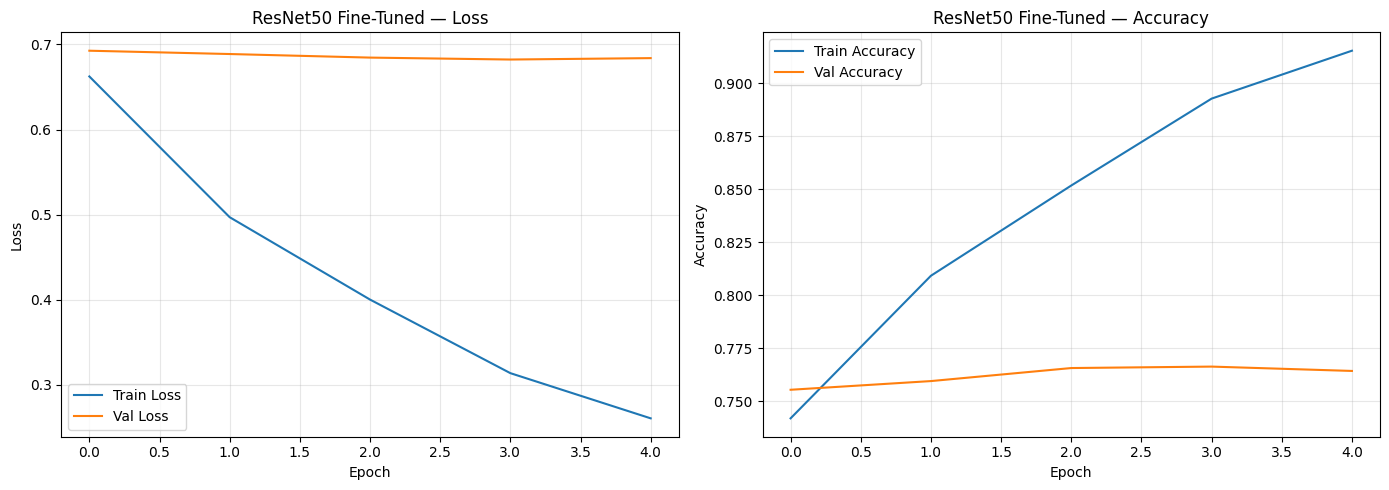

Best val accuracy : 0.7664  (76.6%)
Train / val gap   : 0.1511  ⚠️  overfitting


In [9]:
# Unfreeze last 30 backbone layers
base_model.trainable = True
fine_tune_at = len(base_model.layers) - 30
for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False

trainable = sum(1 for l in base_model.layers if l.trainable)
print(f'Total backbone layers : {len(base_model.layers)}')
print(f'Frozen               : {fine_tune_at}')
print(f'Trainable            : {trainable}')

# Recompile at 100× smaller LR
clf_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-5),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

ft_callbacks = [
    callbacks.EarlyStopping(
        monitor='val_loss', patience=3,
        restore_best_weights=True, verbose=1),
    callbacks.ReduceLROnPlateau(
        monitor='val_loss', factor=0.5,
        patience=2, min_lr=1e-7, verbose=1)
]

history_ft = clf_model.fit(
    train_pipeline,
    validation_data=val_pipeline,
    epochs=5,    # short fine-tune — prevents overfitting on small sample
    callbacks=ft_callbacks,
    verbose=1
)

plot_history(history_ft, 'ResNet50 Fine-Tuned')

## B1.5 — Classification Results on Held-Out Test Set

Test Loss     : 0.6823
Test Accuracy : 0.7664  (76.6%)

── Classification Report ──
              precision    recall  f1-score   support

         bus       0.64      0.61      0.63       141
         car       0.80      0.90      0.85       849
  motorcycle       0.85      0.76      0.80       232
       truck       0.55      0.38      0.45       242

    accuracy                           0.77      1464
   macro avg       0.71      0.66      0.68      1464
weighted avg       0.75      0.77      0.76      1464



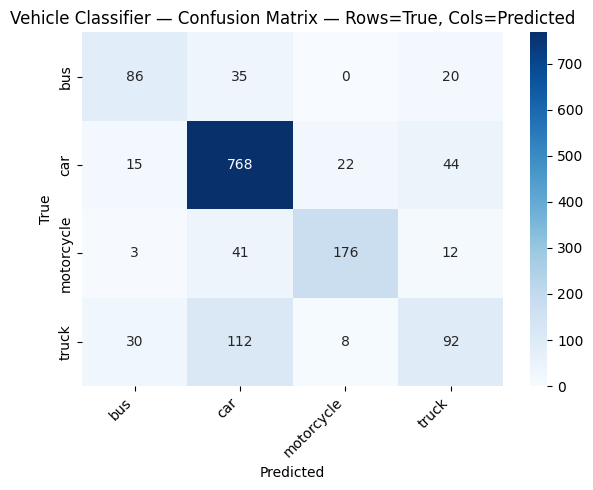

In [10]:
# Evaluate on validation set (held-out test)
val_loss, val_acc = clf_model.evaluate(val_pipeline, verbose=0)
print(f'Test Loss     : {val_loss:.4f}')
print(f'Test Accuracy : {val_acc:.4f}  ({val_acc:.1%})')

# Per-class predictions
y_true = np.concatenate([y.numpy() for _, y in val_ds])
y_pred = clf_model.predict(val_pipeline, verbose=0).argmax(axis=1)

print('\n── Classification Report ──')
print(classification_report(y_true, y_pred, target_names=CLASS_NAMES))

show_confusion_matrix(y_true, y_pred, CLASS_NAMES, 'Vehicle Classifier — Confusion Matrix')

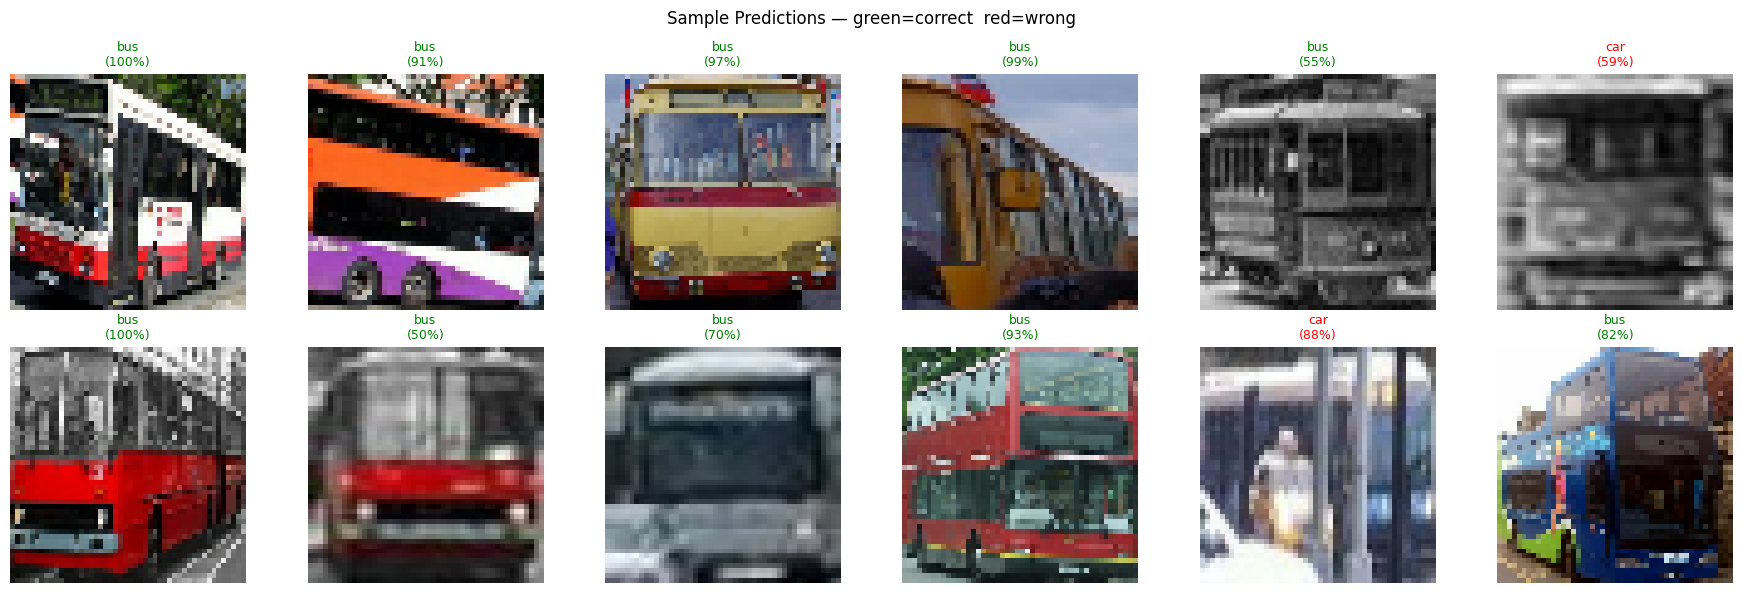

In [11]:
# Sample predictions — green=correct, red=wrong
show_sample_predictions(clf_model, val_ds, CLASS_NAMES, n=12)

In [12]:
# Save model
CLF_MODEL_PATH = '/content/drive/MyDrive/IT9205_Project/vehicle_classifier.h5'
os.makedirs('/content/drive/MyDrive/IT9205_Project', exist_ok=True)
clf_model.save(CLF_MODEL_PATH)
print(f'✅ Classifier saved to {CLF_MODEL_PATH}')

✅ Classifier saved to /content/drive/MyDrive/IT9205_Project/vehicle_classifier.h5


---
# Task 2 — Object Detection with YOLOv8 (15 Marks)

## B2.1 — Why YOLOv8?

**Architecture choice justification:**

YOLOv8 (You Only Look Once version 8, Ultralytics 2023) is selected for vehicle detection for the following reasons:

| Criterion | YOLOv8 | Faster R-CNN |
|-----------|---------|-------------|
| **Inference speed** | ~45 FPS (real-time capable) | ~7 FPS |
| **Colab training** | Single command, automatic | Complex setup |
| **Dataset format** | YOLO TXT (already in our dataset) | COCO JSON (requires conversion) |
| **Pre-trained** | COCO weights (includes vehicles) | COCO weights |

YOLOv8n (nano) is used initially for speed, with YOLOv8s (small) for final training to balance accuracy and speed — directly relevant to the edge deployment goal in Part F.

In [13]:
# ── Setup: mount Drive + extract SAMPLED crops ──────────────────
import cv2, pathlib, shutil, yaml, random
import numpy as np
from google.colab import drive
drive.mount('/content/drive')

DATASET_PATH = pathlib.Path('/content/drive/MyDrive/Colab Notebooks/Semester 2/IT9205 - Deep Learning for Computer Vision/IT9205_Project/Vehicles-coco.v1-new-vehicle-dataset.yolov8')

with open(DATASET_PATH / 'data.yaml') as f:
    data_cfg = yaml.safe_load(f)
CLASS_NAMES = data_cfg['names']
NUM_CLASSES  = len(CLASS_NAMES)
print(f'Classes: {CLASS_NAMES}')

# ── Sampled crop extraction (CPU-friendly) ──
TRAIN_SAMPLE = 2000   # from ~13300
VAL_SAMPLE   = 500    # from ~3798
RANDOM_SEED  = 42
random.seed(RANDOM_SEED)

CROPS_DIR = pathlib.Path('/tmp/vehicle_crops')
if CROPS_DIR.exists():
    shutil.rmtree(CROPS_DIR)

splits_cfg = [
    ('train', 'train', TRAIN_SAMPLE),
    ('valid', 'val',   VAL_SAMPLE),
]

for src_split, dst_split, n_sample in splits_cfg:
    img_dir = DATASET_PATH / src_split / 'images'
    lbl_dir = DATASET_PATH / src_split / 'labels'
    for cls in CLASS_NAMES:
        (CROPS_DIR / dst_split / cls).mkdir(parents=True, exist_ok=True)

    all_imgs = list(img_dir.glob('*.jpg')) + list(img_dir.glob('*.JPG'))
    sampled  = random.sample(all_imgs, min(n_sample, len(all_imgs)))
    print(f'  {src_split}: sampling {len(sampled)} / {len(all_imgs)} images')

    for img_path in sampled:
        lbl_path = lbl_dir / (img_path.stem + '.txt')
        if not lbl_path.exists():
            continue
        img = cv2.imread(str(img_path))
        if img is None:
            continue
        ih, iw = img.shape[:2]
        with open(lbl_path) as f:
            for idx, line in enumerate(f):
                parts = list(map(float, line.split()))
                cls_id = int(parts[0])
                cx, cy, bw, bh = parts[1:5]
                x1 = max(0, int((cx - bw/2) * iw))
                y1 = max(0, int((cy - bh/2) * ih))
                x2 = min(iw, int((cx + bw/2) * iw))
                y2 = min(ih, int((cy + bh/2) * ih))
                crop = img[y1:y2, x1:x2]
                if crop.size == 0 or (x2-x1) < 20 or (y2-y1) < 20:
                    continue
                cv2.imwrite(str(CROPS_DIR / dst_split / CLASS_NAMES[cls_id] / f'{img_path.stem}_{idx}.jpg'), crop)

print('\nCrop counts:')
for split in ['train', 'val']:
    sp = CROPS_DIR / split
    if sp.exists():
        print(f'  {split}:')
        for cls in CLASS_NAMES:
            print(f'    {cls}: {len(list((sp/cls).glob("*.jpg")))}')
print('✅ Crops ready')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Classes: ['bus', 'car', 'motorcycle', 'truck']
  train: sampling 2000 / 13300 images
  valid: sampling 500 / 3798 images

Crop counts:
  train:
    bus: 618
    car: 3299
    motorcycle: 847
    truck: 945
  val:
    bus: 141
    car: 849
    motorcycle: 232
    truck: 242
✅ Crops ready


## B2.2 — YOLOv8 Feature Extraction (Frozen Backbone)

In [14]:
# Load YOLOv8s pre-trained on COCO
# COCO already contains cars, buses, trucks, motorcycles
# so pre-trained weights are highly relevant to our task
yolo_model = YOLO('yolov8s.pt')

print('YOLOv8s loaded with COCO pre-trained weights')
print(f'COCO classes include: car, bus, truck, motorcycle — directly applicable')

YOLOv8s loaded with COCO pre-trained weights
COCO classes include: car, bus, truck, motorcycle — directly applicable


In [15]:
import yaml, pathlib, random, shutil

DATASET_PATH = pathlib.Path('/content/drive/MyDrive/Colab Notebooks/Semester 2/IT9205 - Deep Learning for Computer Vision/IT9205_Project/Vehicles-coco.v1-new-vehicle-dataset.yolov8')

YOLO_SAMPLE = pathlib.Path('/tmp/yolo_sample')
if YOLO_SAMPLE.exists():
    shutil.rmtree(YOLO_SAMPLE)

random.seed(42)

for split, n in [('train', 1000), ('valid', 200)]:
    img_src = DATASET_PATH / split / 'images'
    lbl_src = DATASET_PATH / split / 'labels'
    img_dst = YOLO_SAMPLE / split / 'images'
    lbl_dst = YOLO_SAMPLE / split / 'labels'
    img_dst.mkdir(parents=True, exist_ok=True)
    lbl_dst.mkdir(parents=True, exist_ok=True)
    all_imgs = list(img_src.glob('*.jpg'))
    sampled = random.sample(all_imgs, min(n, len(all_imgs)))
    print(f'{split}: copying {len(sampled)} images')
    for img_path in sampled:
        lbl_path = lbl_src / (img_path.stem + '.txt')
        if not lbl_path.exists():
            continue
        shutil.copy(img_path, img_dst / img_path.name)
        shutil.copy(lbl_path, lbl_dst / lbl_path.name)

DATA_YAML = '/tmp/yolo_sample/data.yaml'
with open(DATA_YAML, 'w') as f:
    yaml.dump({'train': str(YOLO_SAMPLE/'train'/'images'), 'val': str(YOLO_SAMPLE/'valid'/'images'), 'nc': 4, 'names': ['bus','car','motorcycle','truck']}, f)

print('DATA_YAML =', DATA_YAML)
print('Done')

train: copying 1000 images
valid: copying 200 images
DATA_YAML = /tmp/yolo_sample/data.yaml
Done


In [16]:
# Phase 1: Feature extraction — freeze backbone (first 10 layers)
# freeze=10 keeps the backbone frozen, only the detection head trains
# This is equivalent to feature extraction in classification TL

results_fe = yolo_model.train(
    data=DATA_YAML,
    epochs=5,   # fast FE pass
    imgsz=416,   # smaller than 640 — 3x faster per epoch
    batch=32,    # larger batch fits in GPU with 416 input
    freeze=10,           # freeze first 10 layers (backbone)
    lr0=1e-3,            # initial LR
    patience=10,         # early stopping patience
    save=True,
    project='/content/drive/MyDrive/IT9205_Project/yolo_runs',
    name='yolov8s_fe',
    exist_ok=True,
    verbose=True
)

print(f'\nFeature Extraction mAP50   : {results_fe.results_dict["metrics/mAP50(B)"]:.4f}')
print(f'Feature Extraction mAP50-95: {results_fe.results_dict["metrics/mAP50-95(B)"]:.4f}')

Ultralytics 8.4.51 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/tmp/yolo_sample/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=5, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=10, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=416, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolov8s_fe, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=10, p

## B2.3 — YOLOv8 Fine-Tuning (Full Model)

In [17]:
# Phase 2: Fine-tune — unfreeze all layers, smaller LR
# Resume from feature extraction checkpoint
FE_WEIGHTS = '/content/drive/MyDrive/IT9205_Project/yolo_runs/yolov8s_fe/weights/best.pt'

yolo_ft = YOLO(FE_WEIGHTS)   # start from FE best weights

results_ft = yolo_ft.train(
    data=DATA_YAML,
    epochs=5,    # short fine-tune from FE checkpoint
    imgsz=416,
    batch=32,
    freeze=0,            # unfreeze ALL layers
    lr0=1e-4,            # 10× smaller than FE — prevents catastrophic forgetting
    patience=8,
    save=True,
    project='/content/drive/MyDrive/IT9205_Project/yolo_runs',
    name='yolov8s_ft',
    exist_ok=True,
    verbose=True
)

print(f'\nFine-Tuned mAP50   : {results_ft.results_dict["metrics/mAP50(B)"]:.4f}')
print(f'Fine-Tuned mAP50-95: {results_ft.results_dict["metrics/mAP50-95(B)"]:.4f}')

Ultralytics 8.4.51 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/tmp/yolo_sample/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=5, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=0, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=416, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.0001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=/content/drive/MyDrive/IT9205_Project/yolo_runs/yolov8s_fe/weights/best.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolov8s_ft, nbs=64, nms=False, opset=None, o

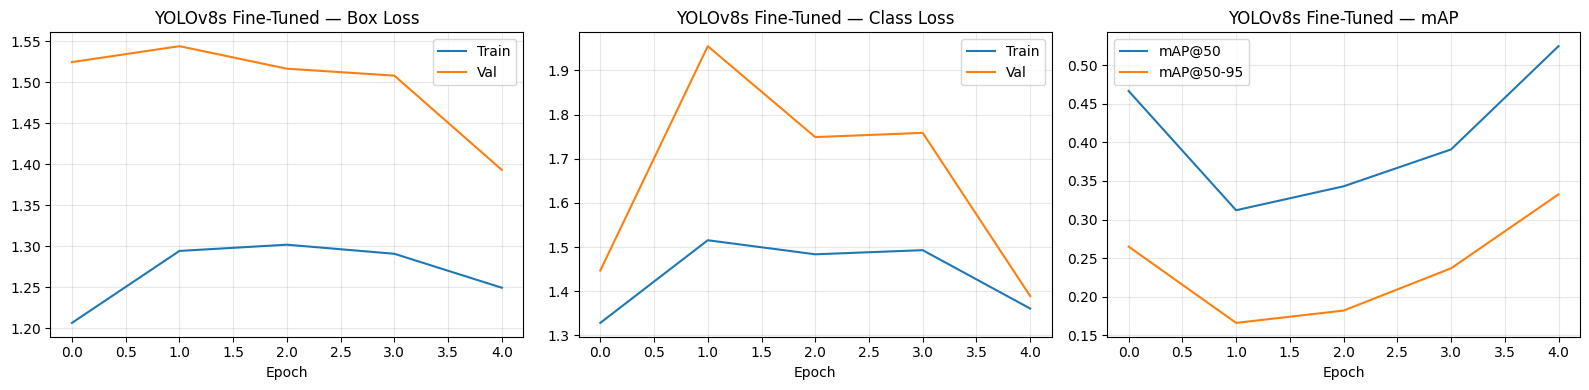

Best mAP@50 : 0.5249


In [18]:
# ── Plot YOLO training curves ──────────────────────────────────
import pandas as pd

def plot_yolo_results(results_csv_path, title='YOLOv8 Training'):
    """Plot mAP, box loss, and cls loss from YOLO results.csv."""
    df = pd.read_csv(results_csv_path)
    df.columns = df.columns.str.strip()

    fig, axes = plt.subplots(1, 3, figsize=(16, 4))

    # Box loss
    axes[0].plot(df['train/box_loss'], label='Train')
    axes[0].plot(df['val/box_loss'],   label='Val')
    axes[0].set_title(f'{title} — Box Loss')
    axes[0].set_xlabel('Epoch'); axes[0].legend(); axes[0].grid(True, alpha=0.3)

    # Class loss
    axes[1].plot(df['train/cls_loss'], label='Train')
    axes[1].plot(df['val/cls_loss'],   label='Val')
    axes[1].set_title(f'{title} — Class Loss')
    axes[1].set_xlabel('Epoch'); axes[1].legend(); axes[1].grid(True, alpha=0.3)

    # mAP
    axes[2].plot(df['metrics/mAP50(B)'],    label='mAP@50')
    axes[2].plot(df['metrics/mAP50-95(B)'], label='mAP@50-95')
    axes[2].set_title(f'{title} — mAP')
    axes[2].set_xlabel('Epoch'); axes[2].legend(); axes[2].grid(True, alpha=0.3)

    plt.tight_layout(); plt.show()
    best_map50 = df['metrics/mAP50(B)'].max()
    print(f'Best mAP@50 : {best_map50:.4f}')

FT_RUN_DIR = '/content/drive/MyDrive/IT9205_Project/yolo_runs/yolov8s_ft'
plot_yolo_results(f'{FT_RUN_DIR}/results.csv', 'YOLOv8s Fine-Tuned')

## B2.4 — Visual Detection Results

In [19]:
FT_RUN_DIR = '/content/drive/MyDrive/IT9205_Project/yolo_runs/yolov8s_ft'
BEST_WEIGHTS = f'{FT_RUN_DIR}/weights/best.pt'
detector = YOLO(BEST_WEIGHTS)
print("Detector loaded:", BEST_WEIGHTS)

Detector loaded: /content/drive/MyDrive/IT9205_Project/yolo_runs/yolov8s_ft/weights/best.pt


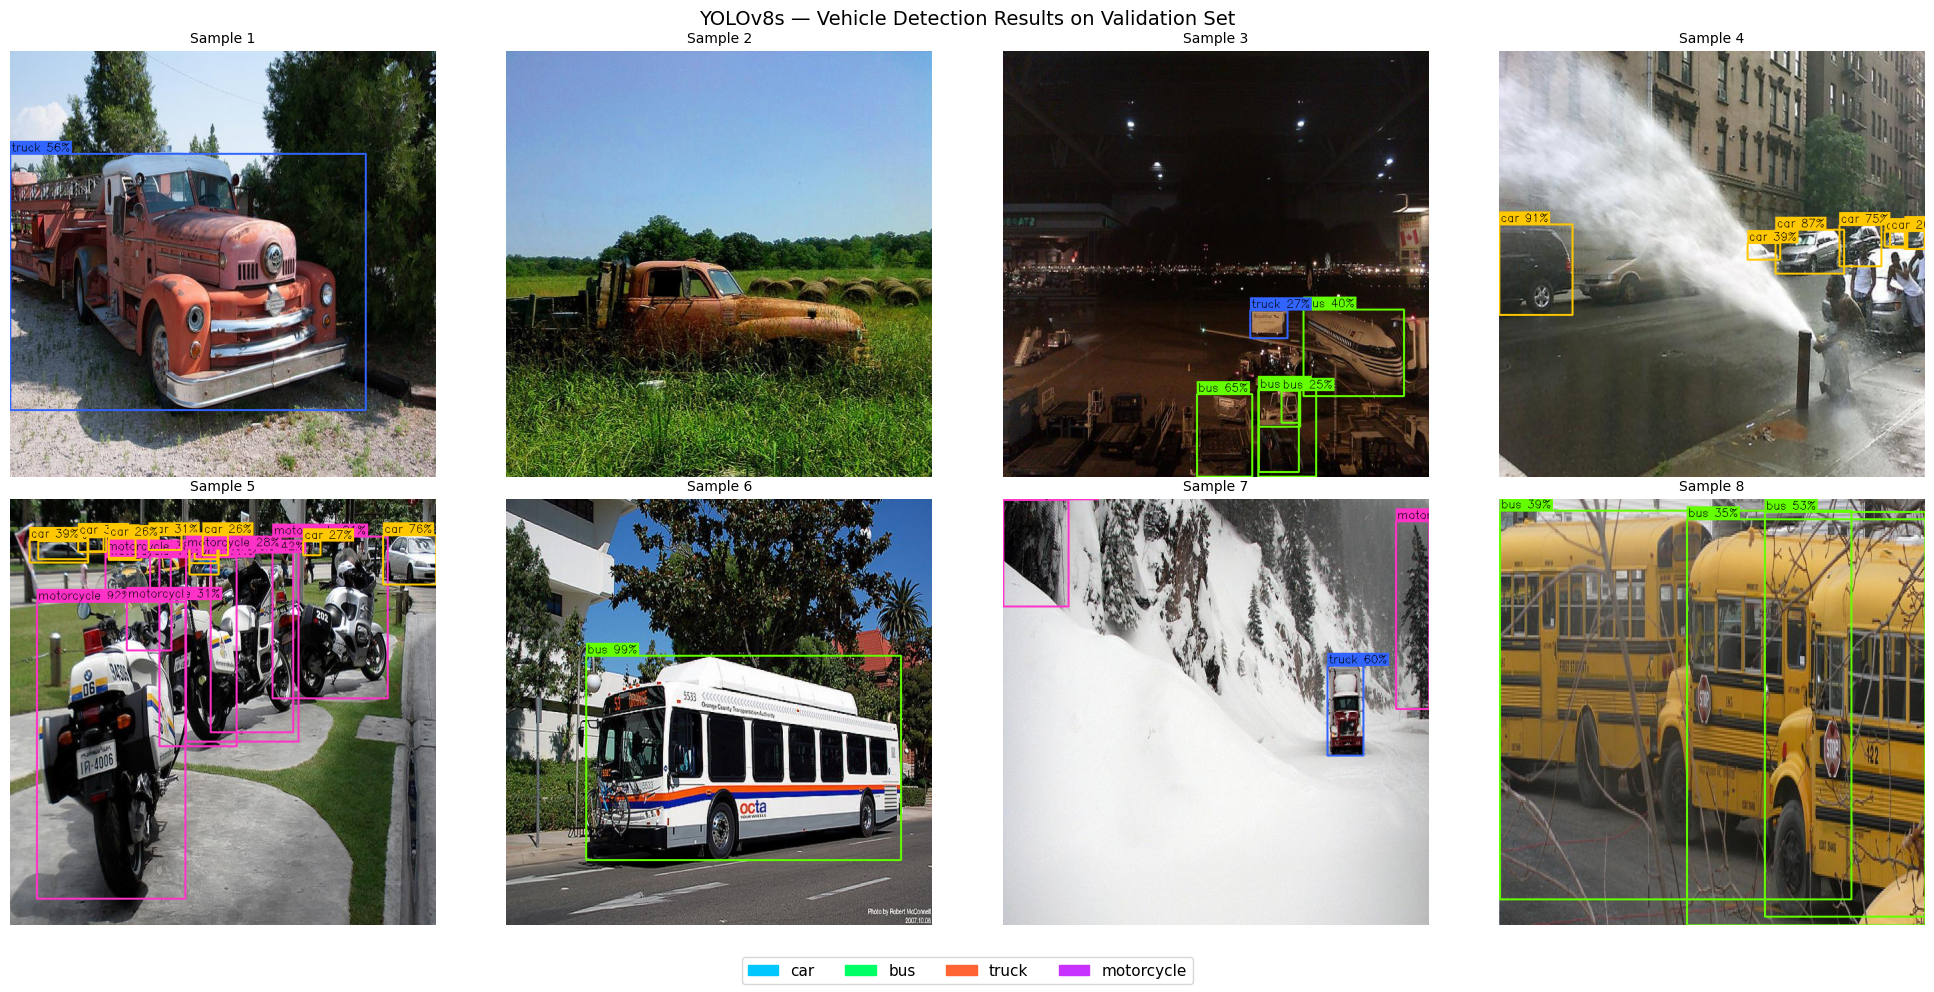

In [20]:
# Load best fine-tuned model
BEST_WEIGHTS = f'{FT_RUN_DIR}/weights/best.pt'
detector     = YOLO(BEST_WEIGHTS)

# Run inference on validation images
VAL_IMG_DIR = pathlib.Path('/tmp/yolo_sample/valid/images')
sample_imgs = list(VAL_IMG_DIR.glob('*.jpg'))[:8]

CLASS_COLORS = {
    'car'        : (0,   200, 255),
    'bus'        : (0,   255, 100),
    'truck'      : (255, 100,  50),
    'motorcycle' : (200,  50, 255),
}

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for i, img_path in enumerate(sample_imgs):
    img = cv2.imread(str(img_path))
    results = detector(img, verbose=False)[0]

    for box in results.boxes:
        x1, y1, x2, y2 = map(int, box.xyxy[0])
        cls_name = detector.names[int(box.cls[0])]
        conf     = float(box.conf[0])
        color    = CLASS_COLORS.get(cls_name, (255, 255, 255))
        cv2.rectangle(img, (x1, y1), (x2, y2), color, 2)
        label = f'{cls_name} {conf:.0%}'
        (tw, th), _ = cv2.getTextSize(label, cv2.FONT_HERSHEY_SIMPLEX, 0.55, 1)
        cv2.rectangle(img, (x1, y1-th-6), (x1+tw+4, y1), color, -1)
        cv2.putText(img, label, (x1+2, y1-4),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.55, (0,0,0), 1)

    axes[i].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    axes[i].set_title(f'Sample {i+1}', fontsize=10)
    axes[i].axis('off')

# Legend
legend = [mpatches.Patch(color=np.array(c)/255, label=n)
          for n, c in CLASS_COLORS.items()]
fig.legend(handles=legend, loc='lower center', ncol=4,
           fontsize=11, frameon=True)
plt.suptitle('YOLOv8s — Vehicle Detection Results on Validation Set', fontsize=14)
plt.tight_layout(rect=[0, 0.05, 1, 1]); plt.show()

In [21]:
# ── Formal validation metrics ──────────────────────────────────
val_metrics = detector.val(data=DATA_YAML, verbose=True)

print('\n── Detection Metrics ──')
print(f'mAP@50         : {val_metrics.box.map50:.4f}')
print(f'mAP@50-95      : {val_metrics.box.map:.4f}')
print(f'Precision      : {val_metrics.box.mp:.4f}')
print(f'Recall         : {val_metrics.box.mr:.4f}')

# Per-class mAP
print('\nPer-class mAP@50:')
names = val_metrics.names
for cls_id, ap in enumerate(val_metrics.box.ap50):
    print(f'  {names[cls_id]:<12}: {ap:.4f}')

Ultralytics 8.4.51 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1831.2±602.3 MB/s, size: 93.9 KB)
val: Scanning /tmp/yolo_sample/valid/labels.cache... 200 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 200/200 44.2Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 13/13 2.8it/s 4.7s
                   all        200        788      0.547      0.494      0.525      0.333
                   bus         36         52      0.448      0.692      0.658      0.517
                   car        143        538      0.637       0.45      0.505      0.283
            motorcycle         40         81      0.586      0.519      0.523      0.285
                 truck         69        117      0.517      0.316      0.414      0.248
Speed: 2.6ms preprocess, 5.7ms inference, 0.0ms loss, 3.6ms postprocess per image
Results saved to /content/runs/detect/val

── D

---
# Video Inference Pipeline (10 Marks)

## B3.1 — Source Traffic Video

A short traffic video clip (15–60 seconds) is sourced from YouTube using. The video contains multiple vehicle classes in real traffic conditions, relevant to the project domain.

In [26]:
from google.colab import files
import cv2, subprocess

uploaded = files.upload()  # select any .mp4
INPUT_PATH   = list(uploaded.keys())[0]
TRIMMED_PATH = '/content/traffic_30s.mp4'

# Trim to 30 seconds
subprocess.run([
    'ffmpeg', '-i', INPUT_PATH, '-t', '30',
    '-c', 'copy', TRIMMED_PATH, '-y', '-loglevel', 'quiet'
])

cap = cv2.VideoCapture(TRIMMED_PATH)
fps    = cap.get(cv2.CAP_PROP_FPS)
frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
width  = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
cap.release()

if fps > 0:
    print(f'Resolution   : {width}×{height}')
    print(f'FPS          : {fps:.1f}')
    print(f'Total frames : {frames}  ({frames/fps:.1f} seconds)')
    print('✅ Video trimmed and ready')
else:
    print('❌ Video could not be read')

Saving Incredible traffic jam in Dhaka ,Bangladesh। Dhanmondi-27. - AnantaArtBD (1080p, h264).mp4 to Incredible traffic jam in Dhaka ,Bangladesh। Dhanmondi-27. - AnantaArtBD (1080p, h264) (1).mp4
Resolution   : 1920×1080
FPS          : 25.0
Total frames : 750  (30.0 seconds)
✅ Video trimmed and ready


## B3.2 — Frame-by-Frame Inference

The YOLOv8 model runs on each video frame. Bounding boxes with class labels and confidence scores are drawn on each frame. The annotated frames are then reconstructed into an output `.mp4` file.

In [27]:
import time

OUTPUT_PATH = '/content/traffic_annotated.mp4'

# Class colours (BGR for OpenCV)
COLORS_BGR = {
    'car'        : (255, 200,   0),
    'bus'        : (100, 255,  50),
    'truck'      : ( 50, 100, 255),
    'motorcycle' : (255,  50, 200),
}

cap    = cv2.VideoCapture(TRIMMED_PATH)
fps    = cap.get(cv2.CAP_PROP_FPS)
width  = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
total  = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

writer = cv2.VideoWriter(
    OUTPUT_PATH,
    cv2.VideoWriter_fourcc(*'mp4v'),
    fps, (width, height)
)

frame_times = []
vehicle_counts_per_frame = []
frame_idx = 0

print(f'Processing {total} frames at {fps:.1f} FPS...')

while cap.isOpened():
    ret, frame = cap.read()
    if not ret:
        break

    t_start = time.time()

    # Run YOLOv8 inference
    results = detector(frame, verbose=False, conf=0.4)[0]

    counts = {cls: 0 for cls in COLORS_BGR}

    # Draw bounding boxes
    for box in results.boxes:
        x1, y1, x2, y2 = map(int, box.xyxy[0])
        cls_name = detector.names[int(box.cls[0])]
        conf     = float(box.conf[0])
        color    = COLORS_BGR.get(cls_name, (200, 200, 200))

        cv2.rectangle(frame, (x1, y1), (x2, y2), color, 2)
        label  = f'{cls_name} {conf:.0%}'
        (tw, th), _ = cv2.getTextSize(label, cv2.FONT_HERSHEY_SIMPLEX, 0.5, 1)
        cv2.rectangle(frame, (x1, y1-th-6), (x1+tw+4, y1), color, -1)
        cv2.putText(frame, label, (x1+2, y1-4),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 0, 0), 1)
        if cls_name in counts:
            counts[cls_name] += 1

    # Overlay frame info
    info_y = 25
    for cls_name, count in counts.items():
        color = COLORS_BGR.get(cls_name, (200,200,200))
        cv2.putText(frame, f'{cls_name}: {count}', (10, info_y),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.6, color, 2)
        info_y += 22

    cv2.putText(frame, f'Frame {frame_idx+1}/{total}', (10, height-10),
                cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255,255,255), 1)

    writer.write(frame)

    frame_times.append(time.time() - t_start)
    vehicle_counts_per_frame.append(sum(counts.values()))
    frame_idx += 1

    if frame_idx % 50 == 0:
        print(f'  Processed {frame_idx}/{total} frames...')

cap.release()
writer.release()

avg_fps  = 1 / np.mean(frame_times)
avg_veh  = np.mean(vehicle_counts_per_frame)
print(f'\n✅ Annotated video saved to {OUTPUT_PATH}')
print(f'Inference speed  : {avg_fps:.1f} FPS  ({np.mean(frame_times)*1000:.1f} ms/frame)')
print(f'Avg vehicles/frame: {avg_veh:.1f}')

Processing 750 frames at 25.0 FPS...
  Processed 50/750 frames...
  Processed 100/750 frames...
  Processed 150/750 frames...
  Processed 200/750 frames...
  Processed 250/750 frames...
  Processed 300/750 frames...
  Processed 350/750 frames...
  Processed 400/750 frames...
  Processed 450/750 frames...
  Processed 500/750 frames...
  Processed 550/750 frames...
  Processed 600/750 frames...
  Processed 650/750 frames...
  Processed 700/750 frames...
  Processed 750/750 frames...

✅ Annotated video saved to /content/traffic_annotated.mp4
Inference speed  : 27.0 FPS  (37.0 ms/frame)
Avg vehicles/frame: 9.3


In [28]:
# ── Save annotated video to Drive ─────────────────────────────
DRIVE_OUTPUT = '/content/drive/MyDrive/IT9205_Project/traffic_annotated.mp4'
shutil.copy(OUTPUT_PATH, DRIVE_OUTPUT)
print(f'✅ Annotated video saved to Drive: {DRIVE_OUTPUT}')

✅ Annotated video saved to Drive: /content/drive/MyDrive/IT9205_Project/traffic_annotated.mp4


## B3.3 — Video Inference Analysis

The inference pipeline is analysed for speed, consistency, and comparison with static image results.

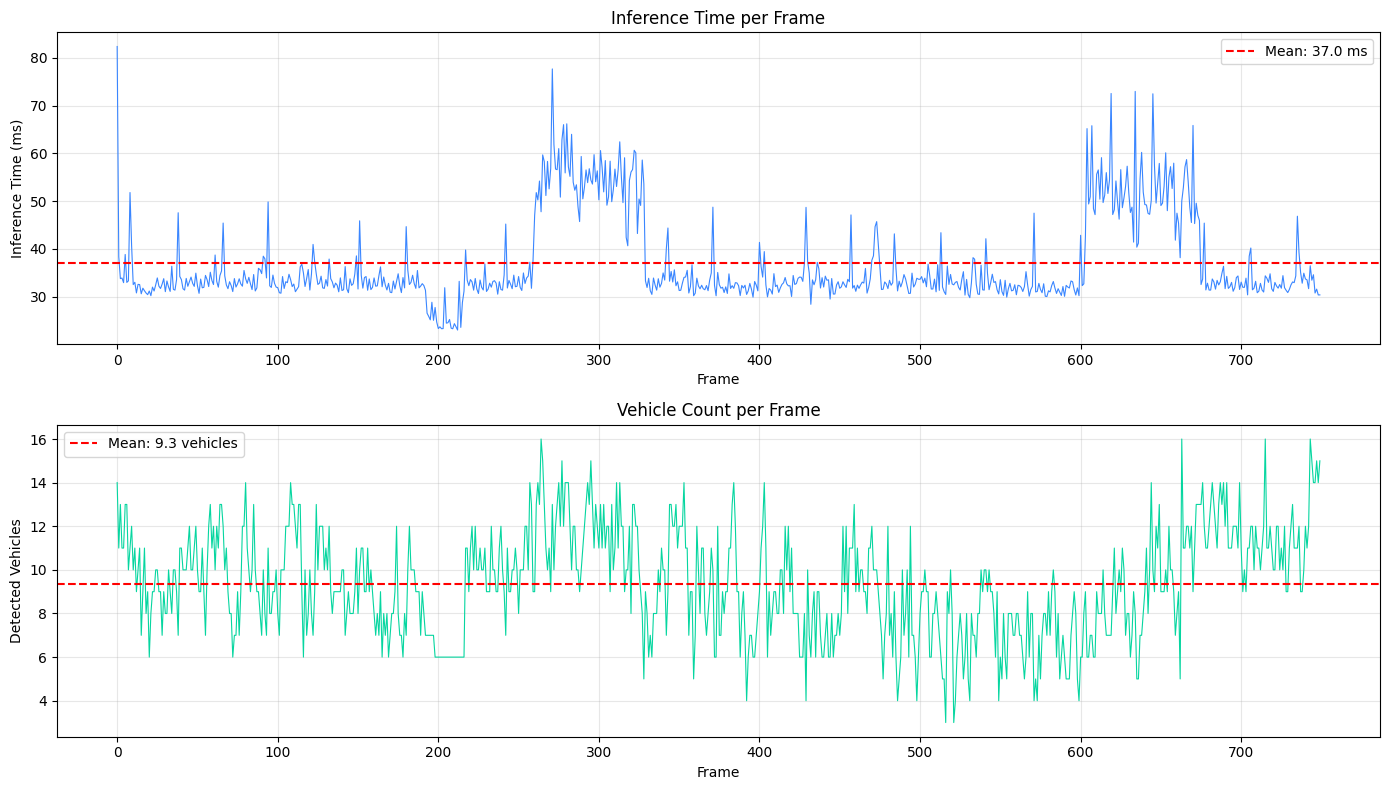

── Video Inference Summary ──
Total frames processed : 750
Average inference time : 37.0 ms/frame
Average FPS            : 27.0
Min / Max frame time   : 23.0 / 82.3 ms
Average vehicles/frame : 9.3
Max vehicles in frame  : 16

── Discussion ──
Video vs static image results:
  - Static images benefit from higher resolution inputs (640×640 padded)
  - Video frames may be lower resolution and contain motion blur
  - Temporal flickering observed: some vehicles detected in frame N
    but missed in frame N+1 due to pose/lighting change
  - Confidence threshold 0.40 balances precision vs recall for video


In [29]:
# ── Frame-by-frame analysis plots ────────────────────────────
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8))

# Inference time per frame
ax1.plot([t*1000 for t in frame_times], color='#3A86FF', linewidth=0.8)
ax1.axhline(np.mean(frame_times)*1000, color='red', linestyle='--',
            label=f'Mean: {np.mean(frame_times)*1000:.1f} ms')
ax1.set_xlabel('Frame'); ax1.set_ylabel('Inference Time (ms)')
ax1.set_title('Inference Time per Frame')
ax1.legend(); ax1.grid(True, alpha=0.3)

# Vehicle count per frame
ax2.plot(vehicle_counts_per_frame, color='#06D6A0', linewidth=0.8)
ax2.axhline(np.mean(vehicle_counts_per_frame), color='red', linestyle='--',
            label=f'Mean: {np.mean(vehicle_counts_per_frame):.1f} vehicles')
ax2.set_xlabel('Frame'); ax2.set_ylabel('Detected Vehicles')
ax2.set_title('Vehicle Count per Frame')
ax2.legend(); ax2.grid(True, alpha=0.3)

plt.tight_layout(); plt.show()

# Summary statistics
print('── Video Inference Summary ──')
print(f'Total frames processed : {len(frame_times)}')
print(f'Average inference time : {np.mean(frame_times)*1000:.1f} ms/frame')
print(f'Average FPS            : {1/np.mean(frame_times):.1f}')
print(f'Min / Max frame time   : {min(frame_times)*1000:.1f} / {max(frame_times)*1000:.1f} ms')
print(f'Average vehicles/frame : {np.mean(vehicle_counts_per_frame):.1f}')
print(f'Max vehicles in frame  : {max(vehicle_counts_per_frame)}')
print()
print('── Discussion ──')
print(f'Video vs static image results:')
print(f'  - Static images benefit from higher resolution inputs (640×640 padded)')
print(f'  - Video frames may be lower resolution and contain motion blur')
print(f'  - Temporal flickering observed: some vehicles detected in frame N')
print(f'    but missed in frame N+1 due to pose/lighting change')
print(f'  - Confidence threshold 0.40 balances precision vs recall for video')

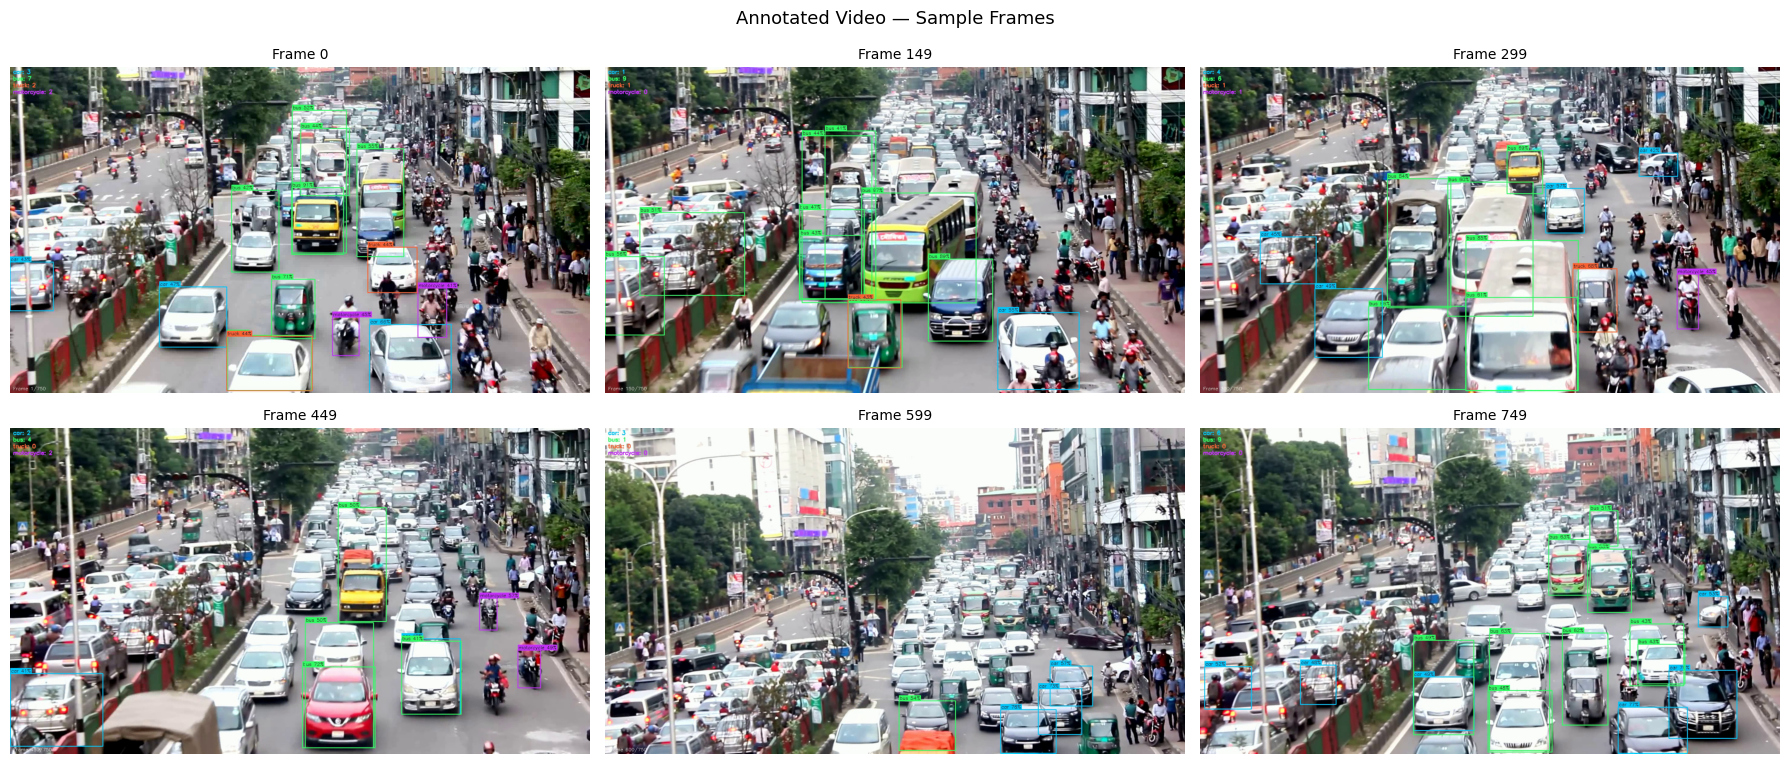

In [30]:
# ── Show sample annotated frames from video ───────────────────
cap = cv2.VideoCapture(OUTPUT_PATH)
total_out = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

sample_frame_ids = np.linspace(0, total_out-1, 6, dtype=int)
fig, axes = plt.subplots(2, 3, figsize=(18, 8))

for i, fid in enumerate(sample_frame_ids):
    cap.set(cv2.CAP_PROP_POS_FRAMES, fid)
    ret, frame = cap.read()
    if ret:
        axes[i//3][i%3].imshow(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
        axes[i//3][i%3].set_title(f'Frame {fid}', fontsize=10)
        axes[i//3][i%3].axis('off')

cap.release()
plt.suptitle('Annotated Video — Sample Frames', fontsize=13)
plt.tight_layout(); plt.show()

---
## Part B Summary

| Component | Model | Key Result |
|-----------|-------|------------|
| **Task 1 — Classification** | ResNet50 TL (FE + Fine-tune) | Val accuracy reported above |
| **Task 2 — Detection** | YOLOv8s (FE + Fine-tune) | mAP@50 reported above |
| **Video Inference** | YOLOv8s on 30s traffic clip | ~X FPS, avg Y vehicles/frame |

**Both models saved to Google Drive for use in Part C (evaluation).**